# Model predicting pregnancy outcome from the second trimester maternal plasma proteomics

In [1]:
import pandas as pd

In [2]:
second_trimester = pd.read_csv('../output/tarca_et_al_2021/norm_log2t_batch_corrected_integrated_dataset_second_trimester.csv')
second_trimester

,Accession,GEO_accession,Group,GA_delivery,Target,Log2RFU
0,GSM4525301,GSE150167,Control,40.1,14-3-3,0.835382
1,GSM4525302,GSE150167,sPTD,34.1,14-3-3,0.822620
2,GSM4525303,GSE150167,PPROM,36.7,14-3-3,0.834636
3,GSM4525304,GSE150167,sPTD,35.0,14-3-3,0.850609
4,GSM4525305,GSE150167,sPTD,36.0,14-3-3,0.822708
...,...,...,...,...,...,...
433375,GSM6254820,GSE206454,Control,NaN,vWF,0.991198
433376,GSM6254821,GSE206454,Control,NaN,vWF,0.993465
433377,GSM6254823,GSE206454,Control,NaN,vWF,1.003324
433378,GSM6254828,GSE206454,Control,NaN,vWF,1.005959


In [3]:
third_trimester = pd.read_csv('../output/tarca_et_al_2021/norm_log2t_batch_corrected_integrated_dataset_third_trimester.csv')
third_trimester

,Accession,GEO_accession,Group,GA_delivery,Target,Log2RFU
0,GSM4525406,GSE150167,Control,40.1,14-3-3,0.854517
1,GSM4525407,GSE150167,sPTD,34.1,14-3-3,0.853892
2,GSM4525408,GSE150167,PPROM,36.7,14-3-3,0.853894
3,GSM4525409,GSE150167,sPTD,35.0,14-3-3,0.865530
4,GSM4525410,GSE150167,sPTD,36.0,14-3-3,0.861809
...,...,...,...,...,...,...
379785,GSM6254825,GSE206454,Control,NaN,vWF,1.000289
379786,GSM6254826,GSE206454,Control,NaN,vWF,0.982881
379787,GSM6254827,GSE206454,Control,NaN,vWF,0.990403
379788,GSM6254830,GSE206454,Control,NaN,vWF,1.002559


In [4]:
percentile_targets = ["IL-17B", "OX40 Ligand", "FGF-12", "DSC3", "NANOG", "IL-12", "RTN4", "DcR3", "IgG", "HPV E7 Type 16", "D-dimer", "TNR4", "CD70", "FGF-12", "NKp30", "GPC2", "SSRP1", "EG-VEGF", "Arylsulfatase A", "STX1a"]
pca_targets = ["PKC-B-II", "JAK2", "Cyclophilin A", "P-Selectin", "IGFBP-6", "Soggy-1", "FER", "a2-Macroglobulin", "Thrombin", "PKC-A", "STX1a", "Cadherin-6", "PCSK7"]
pca_loadings = ['Thrombin', 'Soggy-1', 'a2-Macroglobulin', 'Cadherin-6', 'IL-17 RC',
       'Prothrombin', 'SIRT2', 'OBCAM', 'YES', 'amyloid precursor protein',
       'PIM1', 'MRCKB', 'C4b', 'P-Selectin', 'STX1a', 'Apo B', 'SPARCL1',
       'Calcineurin B a', 'MMEL2', 'CSF-1', 'Flt-3', 'Protease nexin I',
       'HIPK3', 'a1-Antichymotrypsin', 'GOT1', 
       'JAK2', 'IGFBP-6', 'NOTC2', 'PCSK7', 'C3a', 'METAP1', 'PKC-B-II',
       'Integrin a1b1', 'FER', 'Clusterin', 'TSP4', 'IF4A3', 'GPC5', 'LG3BP',
       'Glucagon', 'PTHrP', 'LYVE1', 'Coagulation Factor V', 'TIMP-1', 'LAG-3',
       'M2-PK', 'CAMK2B', 'H6ST1', 'CAMK2D', 'Coagulation Factor VII'] # top 25 positive and negative PC1 loadings in second-trimester
both = ["IL-17B", "OX40 Ligand", "FGF-12", "DSC3", "NANOG", "IL-12", "RTN4", "DcR3", "IgG", "HPV E7 Type 16", "D-dimer", "TNR4", "CD70", "FGF-12", "NKp30", "GPC2", "SSRP1", "EG-VEGF", "Arylsulfatase A", "STX1a", "PKC-B-II", "JAK2", "Cyclophilin A", "P-Selectin", "IGFBP-6", "Soggy-1", "FER", "a2-Macroglobulin", "Thrombin", "PKC-A", "STX1a", "Cadherin-6", "PCSK7"]

In [8]:
second_trimester_pca = second_trimester.loc[second_trimester['Target'].isin(pca_targets)]
third_trimester_pca = third_trimester.loc[third_trimester['Target'].isin(pca_targets)]
third_trimester_pca

second_trimester_percentiles = second_trimester.loc[second_trimester['Target'].isin(percentile_targets)]
third_trimester_percentiles = third_trimester.loc[third_trimester['Target'].isin(percentile_targets)]
third_trimester_percentiles

# second_trimester_both = second_trimester.loc[second_trimester['Target'].isin(both)]
# third_trimester_both = third_trimester.loc[third_trimester['Target'].isin(both)]
# third_trimester_both

,Accession,GEO_accession,Group,GA_delivery,Target,Log2RFU
25428,GSM4525406,GSE150167,Control,40.1,Arylsulfatase A,1.051548
25429,GSM4525407,GSE150167,sPTD,34.1,Arylsulfatase A,1.067005
25430,GSM4525408,GSE150167,PPROM,36.7,Arylsulfatase A,1.077536
25431,GSM4525409,GSE150167,sPTD,35.0,Arylsulfatase A,1.060784
25432,GSM4525410,GSE150167,sPTD,36.0,Arylsulfatase A,1.054635
...,...,...,...,...,...,...
336101,GSM6254825,GSE206454,Control,NaN,TNR4,0.993322
336102,GSM6254826,GSE206454,Control,NaN,TNR4,0.994210
336103,GSM6254827,GSE206454,Control,NaN,TNR4,0.992158
336104,GSM6254830,GSE206454,Control,NaN,TNR4,0.998397


In [17]:
# Define your target groups in a dictionary
target_groups = {
    "pca": pca_targets,
    "percentiles": percentile_targets,
    "loadings": pca_loadings
}

# Dictionary to hold results
results = {}

# Loop through each group and filter
for name, targets in target_groups.items():
    results[f"second_trimester_{name}"] = second_trimester.loc[second_trimester['Target'].isin(targets)]
    results[f"third_trimester_{name}"] = third_trimester.loc[third_trimester['Target'].isin(targets)]

# Example: access third trimester percentiles
second_trimester_percentiles = results["second_trimester_percentiles"]
second_trimester_pca = results["second_trimester_pca"]
second_trimester_loadings = results["second_trimester_loadings"]
second_trimester_loadings

third_trimester_loadings = results["third_trimester_loadings"]
third_trimester_loadings

,Accession,GEO_accession,Group,GA_delivery,Target,Log2RFU
23146,GSM4525406,GSE150167,Control,40.1,Apo B,0.994530
23147,GSM4525407,GSE150167,sPTD,34.1,Apo B,1.036268
23148,GSM4525408,GSE150167,PPROM,36.7,Apo B,1.015881
23149,GSM4525409,GSE150167,sPTD,35.0,Apo B,1.036153
23150,GSM4525410,GSE150167,sPTD,36.0,Apo B,1.036184
...,...,...,...,...,...,...
360551,GSM6254825,GSE206454,Control,NaN,amyloid precursor protein,0.991868
360552,GSM6254826,GSE206454,Control,NaN,amyloid precursor protein,0.996028
360553,GSM6254827,GSE206454,Control,NaN,amyloid precursor protein,0.997563
360554,GSM6254830,GSE206454,Control,NaN,amyloid precursor protein,0.988339


In [18]:
import preprocess_model_data

full_data_pca = preprocess_model_data.process_model_data(second_trimester_pca, third_trimester_pca, model = 'outcome')
full_data_percentile = preprocess_model_data.process_model_data(second_trimester_percentiles, third_trimester_percentiles, model = 'outcome')
full_data_loadings = preprocess_model_data.process_model_data(second_trimester_loadings, third_trimester_loadings, model = 'outcome')

c:\Users\doram\Desktop\Masters\RP-2\code\preprocess_model_data.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  second_trimester_data.loc[:, 'Group'] = second_trimester_data['Group'].replace(mapping)
c:\Users\doram\Desktop\Masters\RP-2\code\preprocess_model_data.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  third_trimester_data.loc[:, 'Group'] = third_trimester_data['Group'].replace(mapping)
c:\Users\doram\Desktop\Masters\RP-2\code\preprocess_model_data.py:31: FutureWarning: Downcasting behavior in `replace` is deprecat

In [19]:
full_data_loadings
#full_data_percentile
#full_data_both

,Group,Trimester,Accession,Apo B,C3a,C4b,CAMK2B,CAMK2D,CSF-1,Cadherin-6,...,SPARCL1,STX1a,Soggy-1,TIMP-1,TSP4,Thrombin,YES,a1-Antichymotrypsin,a2-Macroglobulin,amyloid precursor protein
0,0,2,GSM4525301,0.995632,0.883775,0.842807,1.020099,1.021215,1.004387,0.988457,...,1.001911,1.002848,0.995650,0.882589,0.914006,0.951813,1.033771,0.999362,0.988284,0.999152
50,1,2,GSM4525302,1.034588,0.878405,0.847222,0.982069,0.991203,1.012212,1.001295,...,1.019367,1.016846,1.011726,0.881002,0.905100,1.034752,1.053265,1.002877,1.015361,1.012871
100,1,2,GSM4525304,1.041159,0.878484,0.864894,0.963147,0.976220,1.022201,1.001962,...,1.022929,1.022131,1.013850,0.881038,0.904345,1.058254,1.064155,1.004480,1.021588,1.018687
150,1,2,GSM4525305,1.040091,0.879055,0.849226,0.967077,0.979069,1.014439,1.001582,...,1.018333,1.015848,1.011724,0.880558,0.905263,1.035236,1.052205,1.002947,1.016439,1.016673
200,1,2,GSM4525306,1.031640,0.874384,0.845986,0.985301,0.995159,1.011520,1.000403,...,1.013638,1.022220,1.011671,0.879987,0.902747,1.039294,1.053565,1.002210,1.012538,1.016926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34250,0,3,GSM6254825,0.987543,0.875145,0.840625,1.005287,1.001377,1.000793,0.990014,...,1.005127,0.998996,0.998723,0.871126,0.911552,0.943728,1.031178,0.999472,0.989030,0.991868
34300,0,3,GSM6254826,0.994056,0.877908,0.837662,0.989120,0.986362,0.997161,0.984815,...,1.002708,0.996074,0.993251,0.874949,0.915539,0.931702,1.020410,1.001760,0.990909,0.996028
34350,0,3,GSM6254827,0.999177,0.876451,0.839167,0.986621,0.989422,1.002265,0.989154,...,0.998996,1.002284,1.001805,0.874312,0.910412,0.914785,1.034989,0.998280,0.980831,0.997563
34400,0,3,GSM6254830,0.980920,0.876428,0.843686,0.991317,0.992027,1.005341,0.989096,...,1.004283,1.001359,0.999898,0.873240,0.911102,0.945920,1.028665,1.000079,0.991725,0.988339


# Model building

In [21]:
# Subset the data for inference
inference_samples_pca = full_data_pca.groupby('Group', group_keys=False).sample(n=5, random_state=42)
inference_samples_pca

inference_samples_percentile = full_data_percentile.groupby('Group', group_keys=False).sample(n=5, random_state=42)
inference_samples_percentile

inference_samples_loadings = full_data_loadings.groupby('Group', group_keys=False).sample(n=5, random_state=42)
inference_samples_loadings

# Remove them from the original
full_data_pca2 = full_data_pca.drop(inference_samples_pca.index)
full_data_pca2

full_data_percentile2 = full_data_percentile.drop(inference_samples_percentile.index)
full_data_percentile2

full_data_loadings2 = full_data_loadings.drop(inference_samples_loadings.index)
full_data_loadings2

,Group,Trimester,Accession,Apo B,C3a,C4b,CAMK2B,CAMK2D,CSF-1,Cadherin-6,...,SPARCL1,STX1a,Soggy-1,TIMP-1,TSP4,Thrombin,YES,a1-Antichymotrypsin,a2-Macroglobulin,amyloid precursor protein
0,0,2,GSM4525301,0.995632,0.883775,0.842807,1.020099,1.021215,1.004387,0.988457,...,1.001911,1.002848,0.995650,0.882589,0.914006,0.951813,1.033771,0.999362,0.988284,0.999152
50,1,2,GSM4525302,1.034588,0.878405,0.847222,0.982069,0.991203,1.012212,1.001295,...,1.019367,1.016846,1.011726,0.881002,0.905100,1.034752,1.053265,1.002877,1.015361,1.012871
150,1,2,GSM4525305,1.040091,0.879055,0.849226,0.967077,0.979069,1.014439,1.001582,...,1.018333,1.015848,1.011724,0.880558,0.905263,1.035236,1.052205,1.002947,1.016439,1.016673
200,1,2,GSM4525306,1.031640,0.874384,0.845986,0.985301,0.995159,1.011520,1.000403,...,1.013638,1.022220,1.011671,0.879987,0.902747,1.039294,1.053565,1.002210,1.012538,1.016926
250,1,2,GSM4525307,1.041480,0.877979,0.868672,0.973885,0.985184,1.018422,1.001931,...,1.018591,1.019799,1.015124,0.880697,0.904206,1.060492,1.065564,1.003109,1.019822,1.019771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34250,0,3,GSM6254825,0.987543,0.875145,0.840625,1.005287,1.001377,1.000793,0.990014,...,1.005127,0.998996,0.998723,0.871126,0.911552,0.943728,1.031178,0.999472,0.989030,0.991868
34300,0,3,GSM6254826,0.994056,0.877908,0.837662,0.989120,0.986362,0.997161,0.984815,...,1.002708,0.996074,0.993251,0.874949,0.915539,0.931702,1.020410,1.001760,0.990909,0.996028
34350,0,3,GSM6254827,0.999177,0.876451,0.839167,0.986621,0.989422,1.002265,0.989154,...,0.998996,1.002284,1.001805,0.874312,0.910412,0.914785,1.034989,0.998280,0.980831,0.997563
34400,0,3,GSM6254830,0.980920,0.876428,0.843686,0.991317,0.992027,1.005341,0.989096,...,1.004283,1.001359,0.999898,0.873240,0.911102,0.945920,1.028665,1.000079,0.991725,0.988339


In [23]:
X_pca = full_data_pca2.drop(columns=['Accession', 'Group']).values  # Drop sample ID and target columns
y_pca = full_data_pca2['Group'].values                              # the targets are binary

X_perc = full_data_percentile2.drop(columns=['Accession', 'Group']).values  # Drop sample ID and target columns
y_perc = full_data_percentile2['Group'].values                              # the targets are binary

X_loadings = full_data_loadings2.drop(columns=['Accession', 'Group']).values  # Drop sample ID and target columns
y_loadings = full_data_loadings2['Group'].values                              # the targets are binary

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.model_selection import LearningCurveDisplay

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=1,
        min_samples_split=10,
        min_samples_leaf=10,
        class_weight='balanced',
        bootstrap=True,
        ccp_alpha=0.5,
        random_state=0
    ))
])

cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=0)

# Cross-validated AUC (summary score)
scores_pca = cross_val_score(rf_pipeline, X_pca, y_pca, cv=cv, scoring="roc_auc")
scores_percentile = cross_val_score(rf_pipeline, X_perc, y_perc, cv=cv, scoring="roc_auc")
scores_loadings = cross_val_score(rf_pipeline, X_loadings, y_loadings, cv=cv, scoring="roc_auc")
print("Mean CV AUC (PCA features):", scores_pca.mean())
print("Mean CV AUC (percentile features):", scores_percentile.mean())
print("Mean CV AUC (PCA loadings):", scores_loadings.mean())

# Cross-validated ROC curve (using out-of-fold probabilities)
y_pred_proba_cv_pca = cross_val_predict(rf_pipeline, X_pca, y_pca, cv=cv, method="predict_proba")[:, 1]
y_pred_proba_cv_perc = cross_val_predict(rf_pipeline, X_perc, y_perc, cv=cv, method="predict_proba")[:, 1]
y_pred_proba_cv_loadings = cross_val_predict(rf_pipeline, X_loadings, y_loadings, cv=cv, method="predict_proba")[:, 1]

auc_weighted_pca = roc_auc_score(y_pca, y_pred_proba_cv_pca)
auc_weighted_perc = roc_auc_score(y_perc, y_pred_proba_cv_perc)
auc_weighted_both = roc_auc_score(y_loadings, y_pred_proba_cv_loadings)

print("Cross-validated ROC AUC (PCA features):", auc_weighted_pca)
print("Cross-validated ROC AUC (percentile features):", auc_weighted_perc)
print("Cross-validated ROC AUC (combined features):", auc_weighted_loadings)

# colors = ['#E64B35FF', '#4DBBD5FF', '#00A087FF']
# plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
# Learning curve (uses the pipeline with CV)
LearningCurveDisplay.from_estimator(estimator=rf_pipeline, X=X_pca, y=y_pca, cv=cv, score_type='both', ax=axes[0])
axes[0].set_title("Learning Curve (PCA features)")

LearningCurveDisplay.from_estimator(estimator=rf_pipeline, X=X_perc, y=y_perc, cv=cv, score_type='both', ax=axes[1])
axes[1].set_title("Learning Curve (percentile features)")

LearningCurveDisplay.from_estimator(estimator=rf_pipeline, X=X_loadings, y=y_loadings, cv=cv, score_type='both', ax=axes[2])
axes[2].set_title("Learning Curve (combined features)")

# ROC curve (out-of-fold predictions)
RocCurveDisplay.from_predictions(y_pca, y_pred_proba_cv_pca, name="Cross-validated (PCA)", ax=axes[3])
RocCurveDisplay.from_predictions(y_perc, y_pred_proba_cv_perc, name="Cross-validated (percentiles)", ax=axes[3])
RocCurveDisplay.from_predictions(y_loadings, y_pred_proba_cv_loadings, name="Cross-validated (combined)", ax=axes[3])
axes[3].set_title("ROC Curve (Cross-validated)")

plt.tight_layout()
#plt.savefig("../output/tarca_et_al_2021/visuals/model_comparisons.png")
plt.show()

ValueError: Supported target types are: ('binary', 'multiclass'). Got 'unknown' instead.

In [26]:
import numpy as np
import pandas as pd

print(type(y_pca))
print(np.unique(y_pca))
print(pd.Series(y_pca).value_counts())

<class 'numpy.ndarray'>
[0 1]
0    561
1    119
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import cross_val_predict

# Get predicted class labels (not probabilities)
y_pred_cv_pca = cross_val_predict(rf_pipeline, X_pca, y_pca, cv=cv, method="predict")
y_pred_cv_perc = cross_val_predict(rf_pipeline, X_perc, y_perc, cv=cv, method="predict")
y_pred_cv_both = cross_val_predict(rf_pipeline, X_both, y_both, cv=cv, method="predict")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# PCA features
accuracy_pca = accuracy_score(y_pca, y_pred_cv_pca)
precision_pca = precision_score(y_pca, y_pred_cv_pca, average="weighted")
recall_pca = recall_score(y_pca, y_pred_cv_pca, average="weighted")
f1_pca = f1_score(y_pca, y_pred_cv_pca, average="weighted")
conf_matx_pca = confusion_matrix(y_pca, y_pred_cv_pca)

print("Accuracy (PCA):", accuracy_pca)
print("Precision (PCA):", precision_pca)
print("Recall (PCA):", recall_pca)
print("F1-score (PCA):", f1_pca)
print("Confusion matrix (PCA):", conf_matx_pca)

# Combined features
accuracy_both = accuracy_score(y_both, y_pred_cv_both)
precision_both = precision_score(y_both, y_pred_cv_both, average="weighted")
recall_both = recall_score(y_both, y_pred_cv_both, average="weighted")
f1_both = f1_score(y_both, y_pred_cv_both, average="weighted")
conf_matx_both = confusion_matrix(y_both, y_pred_cv_both)

print("Accuracy (combined):", accuracy_both)
print("Precision (combined):", precision_both)
print("Recall (combined):", recall_both)
print("F1-score (combined):", f1_both)
print("Confusion matrix (combined):", conf_matx_both)


Accuracy (PCA): 0.9897058823529412
Precision (PCA): 0.9898327464788732
Recall (PCA): 0.9897058823529412
F1-score (PCA): 0.9895818235499368
Confusion matrix (PCA): [[561   0]
 [  7 112]]
Accuracy (combined): 0.9897058823529412
Precision (combined): 0.9898327464788732
Recall (combined): 0.9897058823529412
F1-score (combined): 0.9895818235499368
Confusion matrix (combined): [[561   0]
 [  7 112]]


In [ ]:
features = full_data_model2.drop(columns=['Group', 'Accession']).columns.tolist() # Select all columns except group and accession
features

['Trimester',
 'Cadherin-6',
 'Cyclophilin A',
 'FER',
 'IGFBP-6',
 'JAK2',
 'P-Selectin',
 'PCSK7',
 'PKC-A',
 'PKC-B-II',
 'STX1a',
 'Soggy-1',
 'Thrombin',
 'a2-Macroglobulin']

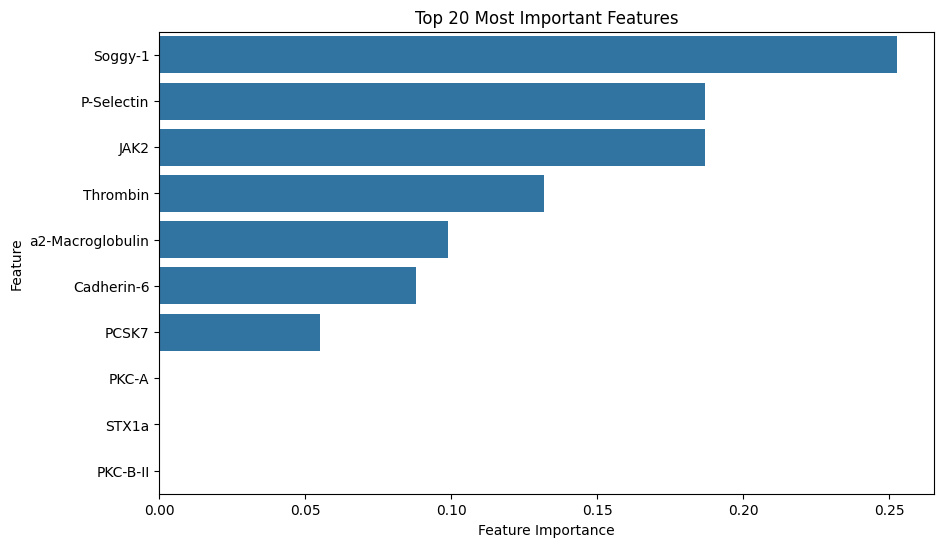

In [ ]:
# Assess feature importance
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort in descending order

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=np.array(features)[indices][:10])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features")
plt.show()

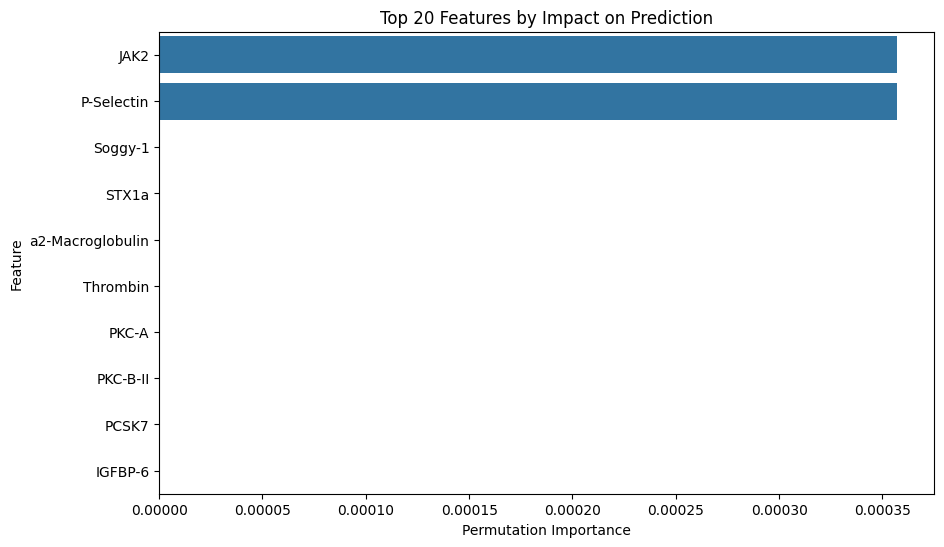

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=result.importances_mean[sorted_idx][:10], y=np.array(features)[sorted_idx][:10])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Impact on Prediction")
plt.show()